[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025-2026, Petr Krysl, pkrysl@ucsd.edu

# GARTEUR SM-AG19 Testbed: Complete

Last updated: 07/15/26

Description

This virtual test application is based on the test article used by the GARTEUR
Structures & Materials Action Group 19 which organized a Round Robin exercise
where 12 European laboratories tested a single structure between 1995 and 1997.
The benchmark structure was a laboratory structure built to simulate the
dynamic behaviour of an aeroplane. The structure was initially built for a
benchmark study on experimental modal analysis conducted by the Structures and
Materials Action Group (SM-AG19) of the Group for Aeronautical Research and
Technology in EURope (GARTEUR). The test-bed was designed and manufactured by
ONERA, France.


![](IMAC97photo.png)

This tutorial includes also the constraining aluminum layer on top of the wing.
The effect of the constraining layer may be overestimated when computing 
the natural frequencies: the flexibility of the viscoelastic layer is omitted.

The purpose is to calculate the natural frequencies and the corresponding mode shapes. The table below summarizes the frequencies found in the experiment.

| Frequency | Hz |
|----------|----------:|
|  1   | 6.38 |
| 2   | 16.10   |
| 3 | 33.12 |
| 4 | 33.53 |
| 5 | 35.65 |
| 6 | 48.38 |
| 7 | 49.43 | 
| 8 | 55.08 |


References

- [GARTEUR] Ground Vibration Test Techniques, compiled by A Gravelle, GARTEUR
  Structures & Materials Action Group 19 Technical report TP-115, 1999.
- [BW] Etienne Balmes, Jan R. Wright, GARTEUR GROUP ON GROUND VIBRATION
  TESTING | RESULTS FROM THE TEST OF A SINGLE STRUCTURE BY 12 LABORATORIES IN
  EUROPE, Proceedings of DETC'97, 1997 ASME Design Engineering Technical
  Conferences, September 14-17, 1997, Sacramento, California.
- [RETT] Sandro R. Rett, Airton Nabarrete, Mariano A. Arbelo, Luiz C. S. Góes, 
  Gustavo P. Guimarães, Results of the GVT of the Unmodified GARTEUR SM-AG19 
  Testbed in South America, 51st AIAA/ASME/ASCE/AHS/ASC Structures, Structural 
  Dynamics, and Materials Conference<BR> 18th, 12 - 15 April 2010, Orlando, 
  Florida, AIAA 2010-2808 



## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


In [113]:
import scipy
import context
from math import pi
from numpy import eye, max, diag
from pystran import model
from pystran import section
from pystran import plots

The material is aluminum, SI units (mm).
The report [GARTEUR] contains an indication which material properties were considered
in the original finite element simulations.


In [114]:
E = 72000.0
G = E / (2 * (1 + 0.3))
rho = 2.7e-9

The cross section properties are given in SI units (mm).

All cross sections are oriented so that the local z axis is aligned with 
the global z (except for the tail).


In [115]:
xz_vector = [0, 0, 1]
xz_vector_tail = [1, 0, 0]

Body.


In [116]:
A, Ix, Iy, Iz, J = section.rectangle(150.0, 50.0)
sbody = section.beam_3d_section(
    "sbody", E=E, rho=rho, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)
print(sbody)

{'name': 'sbody', 'E': 72000.0, 'G': 27692.30769230769, 'rho': 2.7e-09, 'CTE': 0.0, 'A': 7500.0, 'Ix': 15625000.000000002, 'Iy': 14062500.000000002, 'Iz': 1562500.0, 'J': np.float64(4931250.0), 'xy_vector': None, 'xz_vector': array([0, 0, 1])}


Wings. 


In [117]:
A, Ix, Iy, Iz, J = section.rectangle(10.0, 100.0)
swing = section.beam_3d_section(
    "swing", E=E, rho=rho, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

Constraining layer on the wing.


In [118]:
A, Ix, Iy, Iz, J = section.rectangle(1.0, 76.2)
slayer = section.beam_3d_section(
    "slayer", E=E, rho=rho, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)
print(slayer)

{'name': 'slayer', 'E': 72000.0, 'G': 27692.30769230769, 'rho': 2.7e-09, 'CTE': 0.0, 'A': 76.2, 'Ix': 36877.244000000006, 'Iy': 6.3500000000000005, 'Iz': 36870.89400000001, 'J': np.float64(25.109805), 'xy_vector': None, 'xz_vector': array([0, 0, 1])}


Drums.


In [119]:
A, Ix, Iy, Iz, J = section.rectangle(10.0, 100.0)
sdrum = section.beam_3d_section(
    "sdrum", E=E, rho=rho, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

Tail.


In [120]:
A, Ix, Iy, Iz, J = section.rectangle(100.0, 10.0)
stail = section.beam_3d_section(
    "stail", E=E, rho=rho, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector_tail
)

Tailplane.


In [121]:
A, Ix, Iy, Iz, J = section.rectangle(10.0, 100.0)
stplane = section.beam_3d_section(
    "stplane", E=E, rho=rho, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

The offset beams are connected through rigid links.
The rigidity is considered through a diagonal matrix coupling the degrees of freedom, based on the stiffness of a 1mm long beam of the cross section
corresponding to the wing.


In [122]:
srig = section.rigid_link_section("sr", Gamma=1 * diag([E * 100 * 10, E * 100 * 10, E * 100 * 10, E * 100 * 10**3 / 12, E * 100 * 10**3 / 12, E * 100 * 10**3 / 12]))

Create the model.


In [123]:
m = model.create(3)
freedoms = m["freedoms"]

Joints on the body.


In [124]:
model.add_joint(m, 1, [0.0, 0.0, 0.0]) # Under wing
model.add_joint(m, 2, [600.0, 0.0, 0.0]) # Nose
model.add_joint(m, 3, [-900.0, 0.0, 0.0]) # Tail end
model.add_joint(m, 4, [-850.0, 0.0, 0.0]) # Under tail 
model.add_joint(m, 5, [-290.0, 0.0, 0.0]) # Attachment of Bungees  

The wing.


In [125]:
model.add_joint(m, 6, [0.0, 0.0, 96.0]) # Wing root (above body)
model.add_joint(m, 7, [0.0, 1000.0, 96.0]) # Left wing tip
model.add_joint(m, 8, [0.0, 300.0, 96.0]) # Left wing intermediate
model.add_joint(m, 9, [0.0, 600.0, 96.0]) # Left wing intermediate
model.add_joint(m, 10, [0.0, 850.0, 96.0]) # Left wing intermediate (end of constraining layer)
model.add_joint(m, 11, [0.0, 950.0, 96.0]) # Left wing under drum
model.add_joint(m, 12, [0.0, -1000.0, 96.0]) # Right wing tip
model.add_joint(m, 13, [0.0, -300.0, 96.0]) # Right wing intermediate
model.add_joint(m, 14, [0.0, -600.0, 96.0]) # Right wing intermediate
model.add_joint(m, 15, [0.0, -850.0, 96.0]) # Right wing intermediate (end of constraining layer)
model.add_joint(m, 16, [0.0, -950.0, 96.0]) # Right wing under drum

The left drum.


In [126]:
model.add_joint(m, 17, [0.0, 950.0, 106.0]) # Left drum root (above wing)
model.add_joint(m, 18, [200.0, 950.0, 106.0]) # Left drum tip front
model.add_joint(m, 19, [-200.0, 950.0, 106.0]) # Left drum tip rear

The right drum.


In [127]:
model.add_joint(m, 20, [0.0, -950.0, 106.0]) # Right drum root (above wing)
model.add_joint(m, 21, [200.0, -950.0, 106.0]) # Right drum tip front
model.add_joint(m, 22, [-200.0, -950.0, 106.0]) # Right drum tip rear

The tail fin.


In [128]:
model.add_joint(m, 23, [-850.0, 0.0, 50.0]) # Tail fin above body
model.add_joint(m, 24, [-850.0, 0.0, 350.0]) # Tail fin bellow tailplane

The tailplane.


In [129]:
model.add_joint(m, 25, [-850.0, 0.0, 355.0]) # Tailplane above tail fin
model.add_joint(m, 26, [-850.0, 200.0, 355.0]) # Tailplane left tip
model.add_joint(m, 27, [-850.0, -200.0, 355.0]) # Tailplane right tip

Add the attachment points for the compensation masses.


In [130]:
model.add_joint(m, 28, [180.0, +920.0, 106.0]) # Left drum mass
model.add_joint(m, 29, [180.0, -920.0, 106.0]) # Right drum mass

Constraining layer.


In [131]:
model.add_joint(m, 30, [-50+76.2/2, 0.0, 102.6]) # Constraining layer 
model.add_joint(m, 31, [-50+76.2/2, 300.0, 102.6]) # Constraining layer on the left
model.add_joint(m, 32, [-50+76.2/2, 600.0, 102.6]) # Constraining layer on the left
model.add_joint(m, 33, [-50+76.2/2, 850.0, 102.6]) # Constraining layer on the left
model.add_joint(m, 34, [-50+76.2/2, -300.0, 102.6]) # Constraining layer on the right
model.add_joint(m, 35, [-50+76.2/2, -600.0, 102.6]) # Constraining layer on the right
model.add_joint(m, 36, [-50+76.2/2, -850.0, 102.6]) # Constraining layer on the right

Add the body members.


In [132]:
model.add_beam_member(m, 'b1', [1, 2], sbody)
model.add_beam_member(m, 'b2', [1, 5], sbody)
model.add_beam_member(m, 'b3', [3, 4], sbody)
model.add_beam_member(m, 'b4', [4, 5], sbody)

Add the wing members on the left.


In [133]:
model.add_beam_member(m, 'lw1', [6, 8], swing)
model.add_beam_member(m, 'lw2', [8, 9], swing)
model.add_beam_member(m, 'lw3', [9, 10], swing)
model.add_beam_member(m, 'lw4', [10, 11], swing)
model.add_beam_member(m, 'lw5', [11, 7], swing)

Add the wing members on the right.


In [134]:
model.add_beam_member(m, 'rw1', [6, 13], swing)
model.add_beam_member(m, 'rw2', [13, 14], swing)
model.add_beam_member(m, 'rw3', [14, 15], swing)
model.add_beam_member(m, 'rw4', [15, 16], swing)
model.add_beam_member(m, 'rw5', [16, 12], swing)

Add the constraining layer members on the left.


In [135]:
model.add_beam_member(m, 'lcl1', [30, 31], slayer)
model.add_beam_member(m, 'lcl2', [31, 32], slayer)
model.add_beam_member(m, 'lcl3', [32, 33], slayer)

Add the constraining layer members on the right.


In [136]:
model.add_beam_member(m, 'rcl1', [30, 34], slayer)
model.add_beam_member(m, 'rcl2', [34, 35], slayer)
model.add_beam_member(m, 'rcl3', [35, 36], slayer)

Add the left drum members.


In [137]:
model.add_beam_member(m, 'ld1', [17, 18], sdrum)
model.add_beam_member(m, 'ld2', [17, 19], sdrum)

Add the right drum members.


In [138]:
model.add_beam_member(m, 'rd1', [20, 21], sdrum)
model.add_beam_member(m, 'rd2', [20, 22], sdrum)

Add the tail fin member.


In [139]:
model.add_beam_member(m, 'tf', [23, 24], stail)

Add the tailplane members.


In [140]:
model.add_beam_member(m, 'ltp1', [25, 26], stplane)
model.add_beam_member(m, 'ltp2', [25, 27], stplane)

Connect the body and the wing


In [141]:
model.add_rigid_link_member(m, 'bwlink', (1, 6), srig)

Connect the left drum and the wing


In [142]:
model.add_rigid_link_member(m, 'dwllink', (11, 17), srig)

Connect the right drum and the wing


In [143]:
model.add_rigid_link_member(m, 'dwrlink', (16, 20), srig)

Connect the body and the tail


In [144]:
model.add_rigid_link_member(m, 'btlink', (4, 23), srig)

In [145]:
# Connect the tail and the tailplane
model.add_rigid_link_member(m, 'tplink', (24, 25), srig)

In [146]:
# Connect the left drum and the added mass
model.add_rigid_link_member(m, 'mllink', (18, 28), srig)

Connect the right drum and the added mass


In [147]:
model.add_rigid_link_member(m, 'mrlink', (21, 29), srig)

In [148]:
# Connect the wing and the constraining layer
model.add_rigid_link_member(m, 'wlclink1', (6, 30), srig)
model.add_rigid_link_member(m, 'wlclink2', (8, 31), srig)
model.add_rigid_link_member(m, 'wlclink3', (9, 32), srig)
model.add_rigid_link_member(m, 'wlclink4', (10, 33), srig)
model.add_rigid_link_member(m, 'wlclink5', (13, 34), srig)
model.add_rigid_link_member(m, 'wlclink6', (14, 35), srig)
model.add_rigid_link_member(m, 'wlclink7', (15, 36), srig)

Add the masses on the drums.


In [149]:
drum_added_mass = 0.2 / 1000 # convert to metric tons
model.add_mass(m['joints'][28], freedoms.TRANSLATION_DOFS, drum_added_mass)
model.add_mass(m['joints'][28], freedoms.ROTATION_DOFS, drum_added_mass / 100)
model.add_mass(m['joints'][29], freedoms.TRANSLATION_DOFS, drum_added_mass)
model.add_mass(m['joints'][29], freedoms.ROTATION_DOFS, drum_added_mass / 100)

Add the mass of the attachment fixture between the body and the wing.


In [150]:
body_wing_attachment_mass = 16 * 70 * 130 * 7.85e-9 # steel
model.add_mass(m['joints'][6], freedoms.TRANSLATION_DOFS, body_wing_attachment_mass)

Add the mass of the metal of the fixture on the tail


In [151]:
fin_tail_plan_attachment_mass = 2 * 15 * 15 * 100 * 7.85e-9
model.add_mass(m['joints'][12], freedoms.TRANSLATION_DOFS, fin_tail_plan_attachment_mass)

Report the total mass of the model.

In [152]:
vol = model.volume(m)
mass = (rho * vol) + drum_added_mass + body_wing_attachment_mass + fin_tail_plan_attachment_mass
print('Model mass = ', mass * 1000, '[kg]')

Model mass =  41.870968000000005 [kg]


This number is in decent agreement with the mass reported in the various reports and articles.

Lastly, we need to equip the model with the support: the airframe is suspended on bungees. We shall assume that there are two of them to hold the frame. We can assume that the bungees are of stiffness that can be determined by considering the rigid-body vibration  when the entire mass is suspended on them (median of measured rigid-body frequencies is 2.3 Hz). That gives us an estimate of the stiffness coefficient. Here we will assume the nominal mass, rather than the actual mass. The stiffness coefficient needs to be in N/mm (hence we divide by one thousand).

In [153]:
bungee_stiffness = (2 * pi * 2.3)**2 * 44 / 1000 / 2

Therefore, we can now create a uniaxial spring section, acting in the vertical (z) direction.

In [154]:
sbungee = section.spring_section('bungee', 'extension', [0, 0, 1], bungee_stiffness)


Now we need to create a joint that will represent the "ground" to which the bungees are attached. The "ground" will be assumed to be immovable.

In [155]:
model.add_joint(m, 'ground', [0, 0, 0])
model.add_support(m['joints']['ground'], freedoms.ALL_DOFS)


Finally we create the springs for each of the bungees.

In [156]:
model.add_spring_member(m, 'bungee_front', ['ground', 1], sbungee)
model.add_spring_member(m, 'bungee_rear', ['ground', 5], sbungee)

Now we need to create a joint that will represent the "ground" to which the bungees are attached. The "ground" will be assumed to be immovable.

Now let us look at the make up of the model. Notice the rigid connectors shown in green.

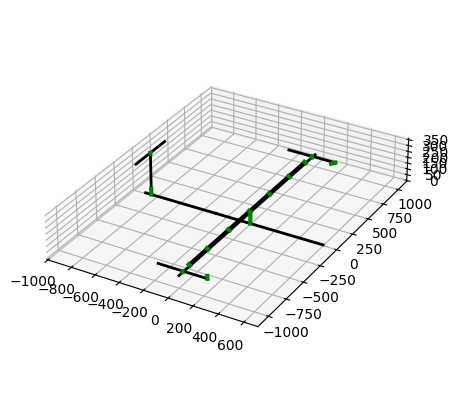

In [157]:
plots.setup(m)
# plots.plot_joint_ids(m)
plots.plot_members(m)
# plots.plot_member_orientation(m)
plots.show(m)

Solve the free-vibration problem.


In [158]:
model.number_dofs(m)
model.solve_free_vibration(m, 1.0)

Plot the modes and compare the frequencies. The mode shapes correlate with
those published in the reference. Note the experimentally determined frequencies given in the table in the introduction.
In particular, our model predicts 6.30 Hz which should be compared with the 6.38 Hz frequency in the experiment.


In [159]:
6.30/6.38

0.9874608150470219

This indicates about an error of 2.3% on the fundamental frequency. It is also important to try to correlate the mode shapes.
The reference [RETT] is used here. The function below will print out the frequency information and display the mode shape.

In [160]:
def show_mode(mode):
    mode += 5
    print(f"Mode {mode+1-6}: {m['frequencies'][mode]:.3f} Hz")
    ax = plots.setup(m)
    plots.plot_members(m)
    model.set_solution(m, m["eigvecs"][:, mode])
    plots.plot_deformations(m, 15.0)
    ax.set_title(f"Mode {mode+1-6}, frequency = {m['frequencies'][mode]:.2f} Hz")
    plots.show(m)

Mode 1: 6.299 Hz


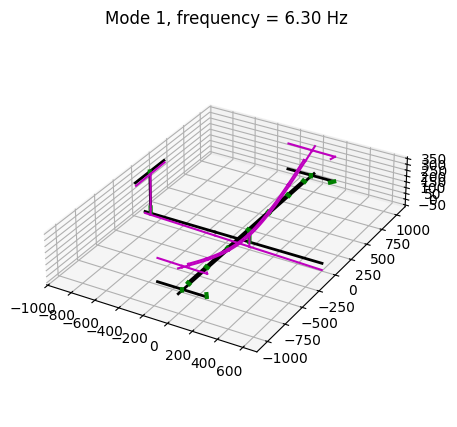

In [161]:
show_mode(1)

![](garteur-mode-1.png)  
Reference [RETT], Figure 9. 

This mode shape correlates nicely with our prediction.

Mode 2: 18.565 Hz


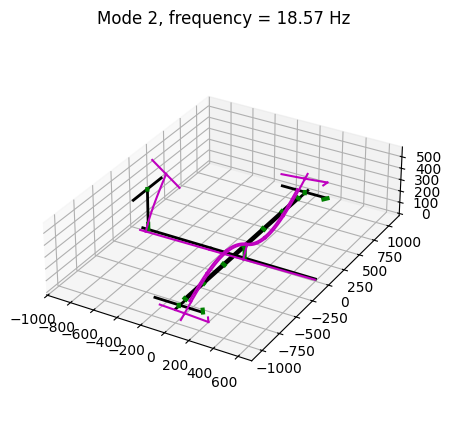

In [162]:
show_mode(2)

![](garteur-mode-2.png)  
Reference [RETT], Figure 9.

We can also match mode 2.


Mode 3: 32.439 Hz


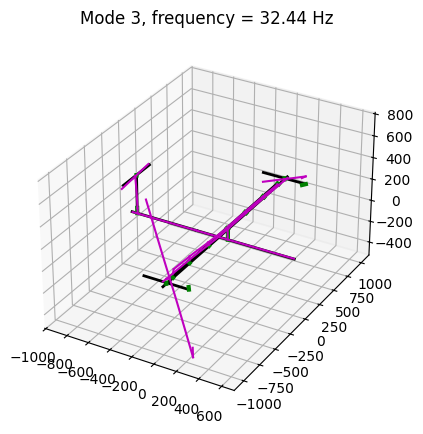

In [163]:
show_mode(3)

![](garteur-mode-3.png)  
Reference [RETT], Figure 9.

Modes 2 and 3 are confusingly very similar in the reference. Our modes 3 and 4 appear to be 4 and 5 in the reference.

Mode 4: 32.506 Hz


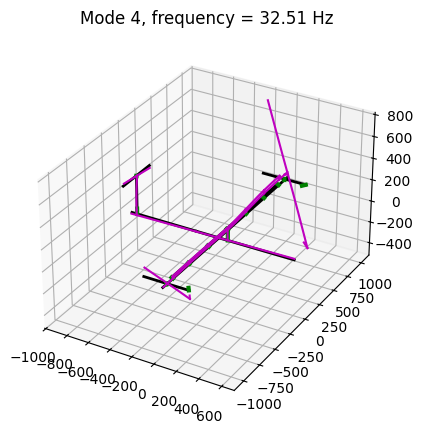

In [164]:
show_mode(4)

![](garteur-mode-4.png)  
Reference [RETT], Figure 9.

Mode 5: 37.344 Hz


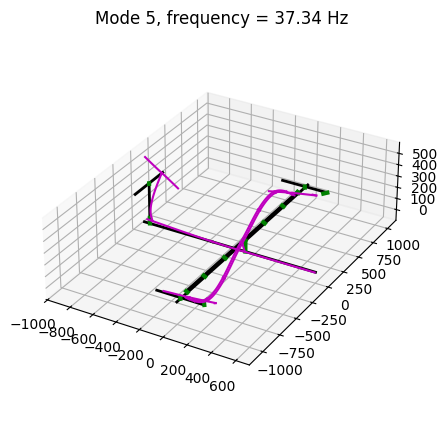

In [165]:
show_mode(5)

![](garteur-mode-5.png)  Reference [RETT], Figure 9.

Mode 6: 44.779 Hz


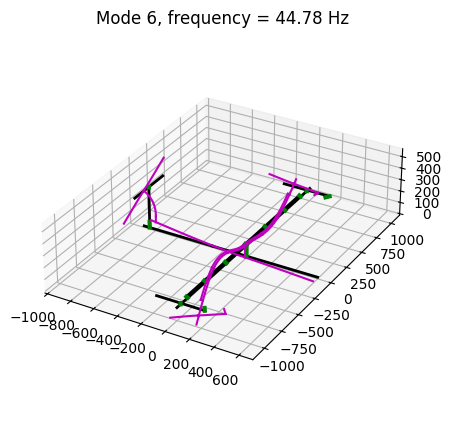

In [166]:
show_mode(6)

![](garteur-mode-6.png)  
Reference [RETT], Figure 9.

This appears to be our mode 7.

Mode 7: 48.000 Hz


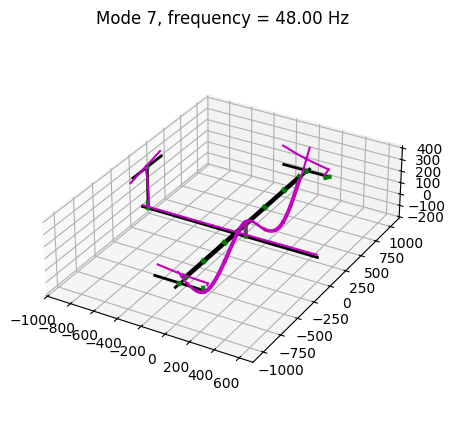

In [167]:
show_mode(7)

![](garteur-mode-7.png)  
Reference [RETT], Figure 9.

This appears to be our mode 6.

Mode 8: 53.876 Hz


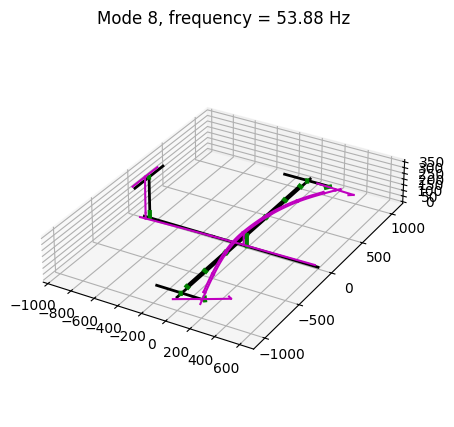

In [168]:
show_mode(8)

![](garteur-mode-8.png) 
Reference [RETT], Figure 9.

The modes 8 appear to match.

## Conclusions

The agreement of the computed frequencies with the experimentally determined frequencies is not better, but given the results of the round robbin exercise, our accuracy is par for the course.